### Exploração inicial `SLCE3`. Quais relações podemos identificar?

#### Apresentação e tratamento

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error


# Carrega o dataset
df = pd.read_csv('SLCE3.csv')

# Exibe as primeiras 5 linhas do DataFrame
print("Primeiras 5 linhas do DataFrame:")
print(df.head())

# Exibe informações gerais sobre o DataFrame
print("\nInformações gerais do DataFrame:")
print(df.info())


# Verifica se há valores negativos nas colunas 'Close' e 'Open'
print("\nVerificando valores negativos nas colunas 'Close' e 'Open':")
negative_close = df[df['Close'] < 0]
negative_open = df[df['Open'] < 0]
negative_high = df[df['High'] < 0]
negative_low = df[df['Low'] < 0]
negative_volum = df[df['Volume'] < 0]

if negative_close.empty:
    print("\nNão há valores negativos na coluna 'Close'.")

if negative_open.empty:
    print("Não há valores negativos na coluna 'Open'.")

if negative_high.empty:
    print("Não há valores negativos na coluna 'High'.")

if negative_low.empty:
    print("Não há valores negativos na coluna 'Low'.")

if negative_volum.empty:
    print("Não há valores negativos na coluna 'Volume'.")



Primeiras 5 linhas do DataFrame:
         Date     Close      High       Low      Open   Volume
0  2018-01-02  3.077934  3.103537  2.972182  2.972182  1227908
1  2018-01-03  3.104650  3.215968  3.067915  3.077933  2494536
2  2018-01-04  3.092405  3.198157  3.055670  3.104650  2957724
3  2018-01-05  3.150290  3.166988  3.069028  3.138046  2140248
4  2018-01-08  3.133592  3.183685  3.112442  3.150290  1613172

Informações gerais do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1738 entries, 0 to 1737
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    1738 non-null   object 
 1   Close   1738 non-null   float64
 2   High    1738 non-null   float64
 3   Low     1738 non-null   float64
 4   Open    1738 non-null   float64
 5   Volume  1738 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 81.6+ KB
None

Verificando valores negativos nas colunas 'Close' e 'Open':

Não há valores negativo

#### Adicionando colunas de valores futuros

In [4]:
df['Close_Open_Diff'] = df['Close'] - df['Open']

print("Primeiras 5 linhas do DataFrame com a nova coluna 'Close_Open_Diff':")
print(df.head())

sns.set_style("whitegrid")

print("\nEstatísticas descritivas do DataFrame (com 'Close_Open_Diff'):")
print(df.describe())

df['Close_1d_fut'] = df['Close'].shift(-1)
df['Close_3d_fut'] = df['Close'].shift(-3)
df['Close_7d_fut'] = df['Close'].shift(-7)
df['Close_15d_fut'] = df['Close'].shift(-15)
df['Close_30d_fut'] = df['Close'].shift(-30)
df['Volume_1d_fut'] = df['Volume'].shift(-1)
df['Volume_3d_fut'] = df['Volume'].shift(-3)
df['Volume_7d_fut'] = df['Volume'].shift(-7)
df['Volume_15d_fut'] = df['Volume'].shift(-15)
df['Volume_30d_fut'] = df['Volume'].shift(-30)

print("\nPrimeiras linhas com colunas de fechamento futuro:")
print(df[['Close', 'Close_1d_fut', 'Close_3d_fut', 'Close_7d_fut', 'Close_15d_fut', 'Close_30d_fut']].head(35))

df_process = df.dropna(subset=['Close_1d_fut', 'Close_3d_fut', 'Close_7d_fut', 'Close_15d_fut', 'Close_30d_fut']).copy()

# df_process.to_csv('SLCE3_process.csv', index=False)
# print("DataFrame processado salvo como 'SLCE3_process.csv'.")


Primeiras 5 linhas do DataFrame com a nova coluna 'Close_Open_Diff':
         Date     Close      High       Low      Open   Volume  \
0  2018-01-02  3.077934  3.103537  2.972182  2.972182  1227908   
1  2018-01-03  3.104650  3.215968  3.067915  3.077933  2494536   
2  2018-01-04  3.092405  3.198157  3.055670  3.104650  2957724   
3  2018-01-05  3.150290  3.166988  3.069028  3.138046  2140248   
4  2018-01-08  3.133592  3.183685  3.112442  3.150290  1613172   

   Close_Open_Diff  
0         0.105752  
1         0.026716  
2        -0.012245  
3         0.012245  
4        -0.016698  

Estatísticas descritivas do DataFrame (com 'Close_Open_Diff'):
             Close         High          Low         Open        Volume  \
count  1738.000000  1738.000000  1738.000000  1738.000000  1.738000e+03   
mean     12.853513    13.075743    12.651012    12.864267  3.029539e+06   
std       5.343477     5.411924     5.279755     5.346681  1.646280e+06   
min       3.077934     3.103537     2.972182

#### Valor de fechamento em função do tempo.


Gráfico 'Preço de Fechamento ao Longo do Tempo' salvo como 'close_price_over_time_full.png'


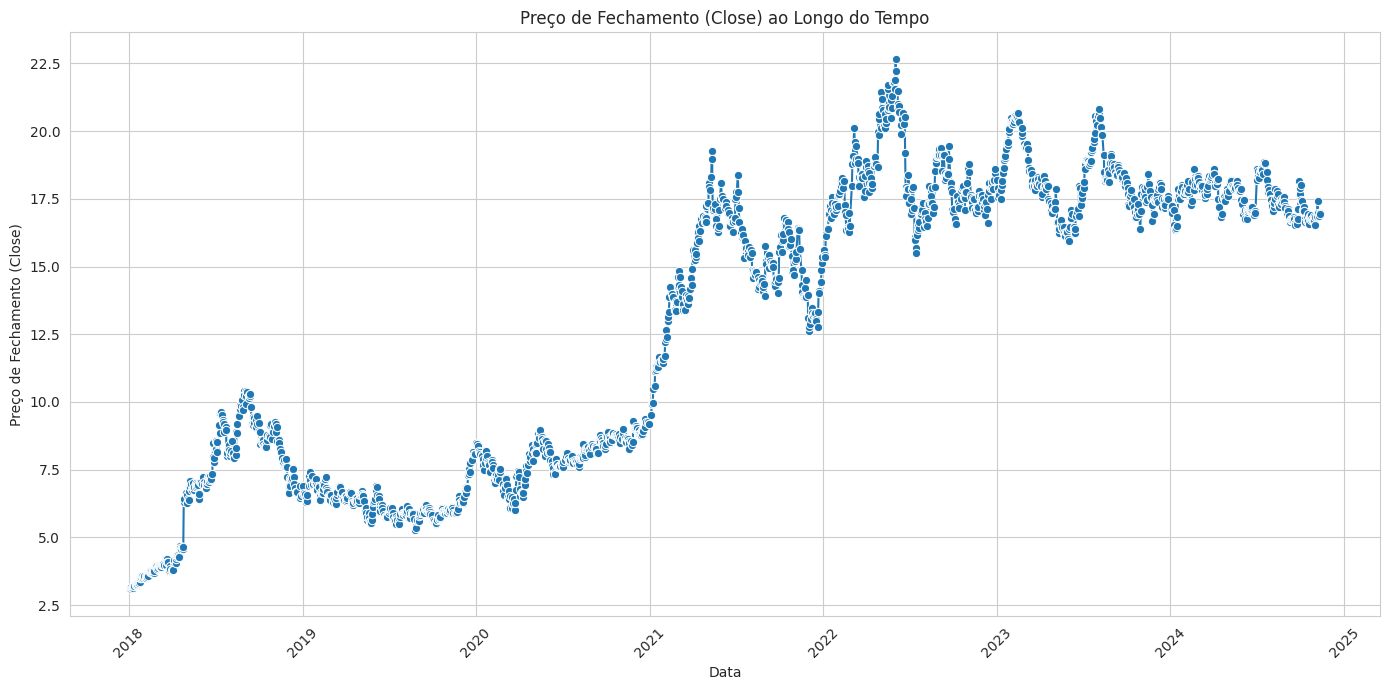

In [5]:
df_process['Date'] = pd.to_datetime(df_process['Date'])
df_process.set_index('Date', inplace=True)

plt.figure(figsize=(14, 7))
sns.lineplot(x=df_process.index, y=df_process['Close'], marker='o', linestyle='-')
plt.title('Preço de Fechamento (Close) ao Longo do Tempo')
plt.xlabel('Data')
plt.ylabel('Preço de Fechamento (Close)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('close_price_over_time_full.png')
print("\nGráfico 'Preço de Fechamento ao Longo do Tempo' salvo como 'close_price_over_time_full.png'")


#### Analise aprofundada de 2021


Gráfico 'Preço de Fechamento 2021 e 2022' salvo como 'close_price_2021_2022.png'


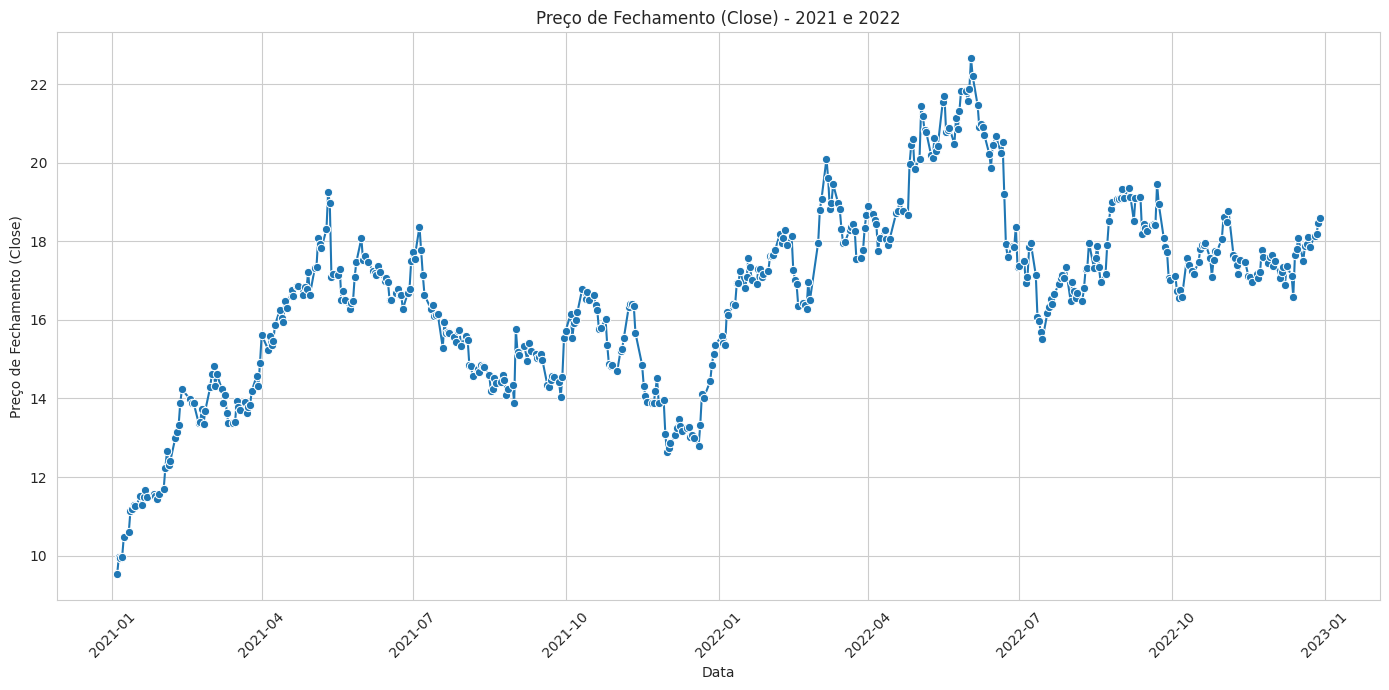

In [6]:
# Garante que o índice é DatetimeIndex
if not isinstance(df_process.index, pd.DatetimeIndex):
	df_process.index = pd.to_datetime(df_process.index)

df_2021_2022 = df_process.loc[(df_process.index.year >= 2021) & (df_process.index.year <= 2022)]

plt.figure(figsize=(14, 7))
sns.lineplot(x=df_2021_2022.index, y=df_2021_2022['Close'], marker='o', linestyle='-')
plt.title('Preço de Fechamento (Close) - 2021 e 2022')
plt.xlabel('Data')
plt.ylabel('Preço de Fechamento (Close)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('close_price_2021_2022.png')
print("\nGráfico 'Preço de Fechamento 2021 e 2022' salvo como 'close_price_2021_2022.png'")



#### Adicionando variaveis dicotômicas para 2021-05-05 e 2022-02-07

In [7]:
# Criação das variáveis dicotômicas
df_process['dummy_2021'] = (df_process.index >= pd.to_datetime('2021-05-05')).astype(int)
df_process['dummy_2022'] = (df_process.index >= pd.to_datetime('2022-02-07')).astype(int)
df_process.to_csv('SLCE3_process_dicotomic.csv', index=True)
print("DataFrame salvo como 'SLCE3_process_dicotomic.csv'.")


DataFrame salvo como 'SLCE3_process_dicotomic.csv'.


#### Treinando o medelo de regressão linear simples com 2 variaveis dicotômicas Close x Low


Gráfico salvo como 'regressao_low_dummies_close.png'

Métricas do Modelo com Dummies:
Coeficientes: [ 1.01934537 -0.01277337 -0.08642309]
Intercepto: 0.0028
R-quadrado (R²): 0.9990


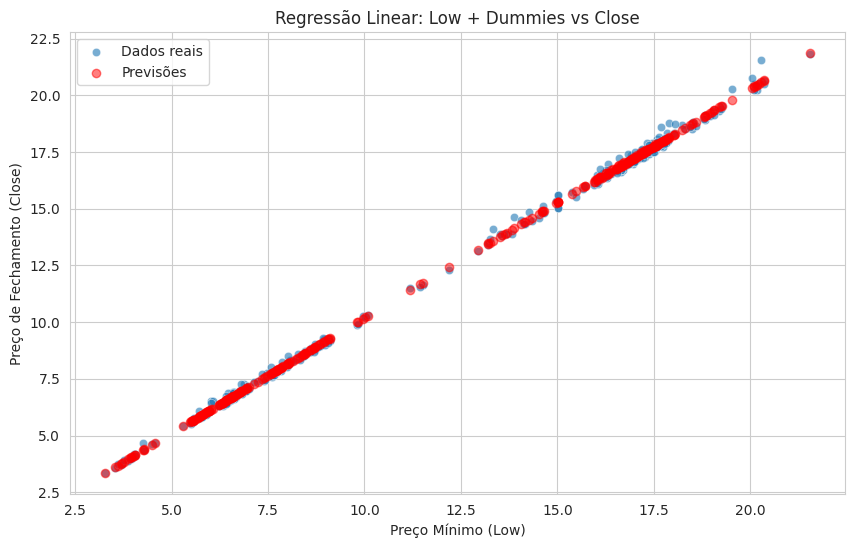

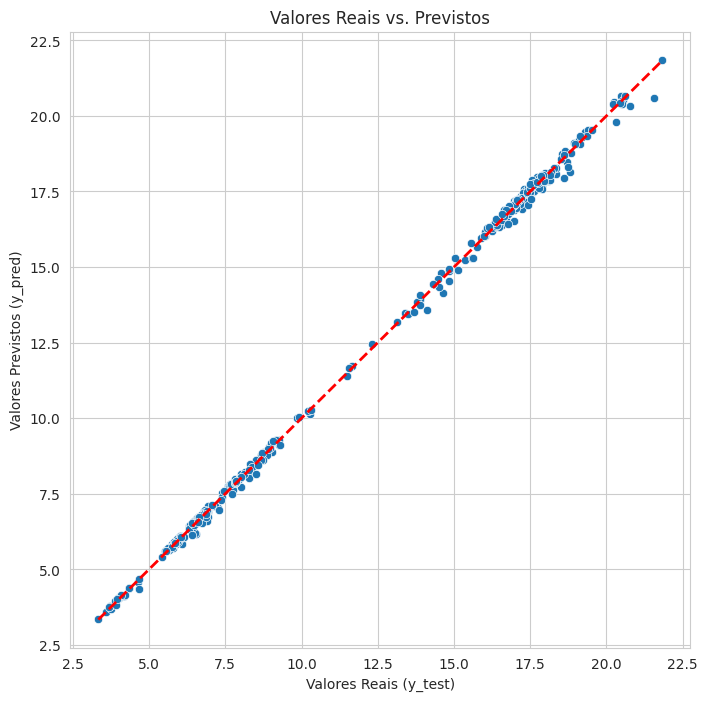

In [8]:
# Variável dependente
y = df_process['Close']

# Seleciona as variáveis independentes: 'Low', 'dummy_2021', 'dummy_2022'
X = df_process[['Low', 'dummy_2021', 'dummy_2022']]

# Divide os dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Inicializa e treina o modelo
model = LinearRegression()
model.fit(X_train, y_train)

# Faz previsões
y_pred = model.predict(X_test)

# Visualização
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test['Low'], y=y_test, alpha=0.6, label='Dados reais')
plt.scatter(X_test['Low'], y_pred, color='red', alpha=0.5, label='Previsões')
plt.title('Regressão Linear: Low + Dummies vs Close')
plt.xlabel('Preço Mínimo (Low)')
plt.ylabel('Preço de Fechamento (Close)')
plt.legend()
plt.grid(True)
plt.savefig('regressao_low_dummies_close.png')
print("\nGráfico salvo como 'regressao_low_dummies_close.png'")

# Métricas
print("\nMétricas do Modelo com Dummies:")
print(f"Coeficientes: {model.coef_}")
print(f"Intercepto: {model.intercept_:.4f}")
print(f"R-quadrado (R²): {model.score(X_test, y_test):.4f}")


# Gráfico de Real vs. Previsto
plt.figure(figsize=(8, 8))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Linha de referência
plt.xlabel('Valores Reais (y_test)')
plt.ylabel('Valores Previstos (y_pred)')
plt.title('Valores Reais vs. Previstos')
plt.grid(True)
plt.show()

#### Treinando o medelo de regressão linear simples com 2 variaveis dicotômicas Close x Low para 1 dias no futuro


Gráfico salvo como 'regressao_low_dummies_close_1d_fut.png'

Métricas do Modelo com Dummies (Close_1d_fut):
Coeficientes: [ 1.01555042  0.00319865 -0.07879032]
Intercepto: 0.0473
R-quadrado (R²): 0.9958


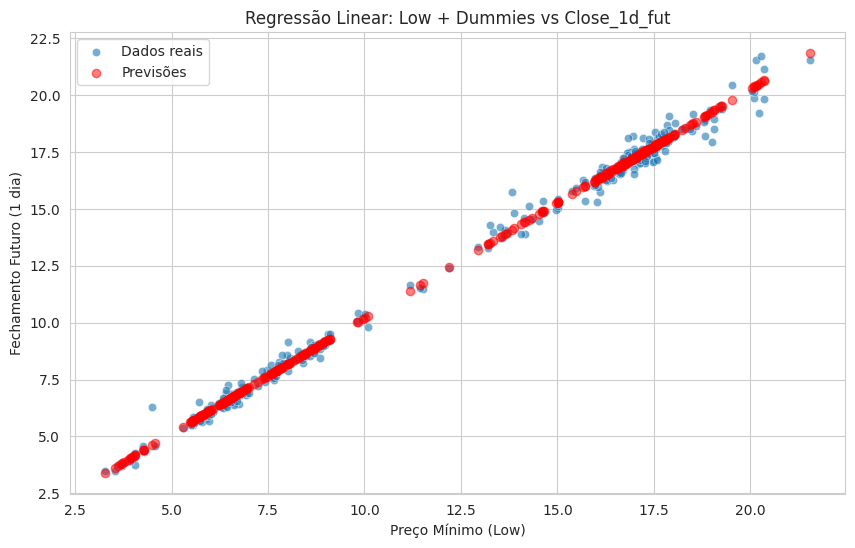

In [9]:
# Variável dependente: fechamento 1 dia no futuro
y_1d = df_process['Close_1d_fut']

# Variáveis independentes: 'Low', 'dummy_2021', 'dummy_2022'
X = df_process[['Low', 'dummy_2021', 'dummy_2022']]

# Divide os dados em treino e teste
X_train, X_test, y_train_1d, y_test_1d = train_test_split(X, y_1d, test_size=0.2, random_state=42)

# Inicializa e treina o modelo
model_1d = LinearRegression()
model_1d.fit(X_train, y_train_1d)

# Faz previsões
y_pred_1d = model_1d.predict(X_test)

# Visualização
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test['Low'], y=y_test_1d, alpha=0.6, label='Dados reais')
plt.scatter(X_test['Low'], y_pred_1d, color='red', alpha=0.5, label='Previsões')
plt.title('Regressão Linear: Low + Dummies vs Close_1d_fut')
plt.xlabel('Preço Mínimo (Low)')
plt.ylabel('Fechamento Futuro (1 dia)')
plt.legend()
plt.grid(True)
plt.savefig('regressao_low_dummies_close_1d_fut.png')
print("\nGráfico salvo como 'regressao_low_dummies_close_1d_fut.png'")

# Métricas
print("\nMétricas do Modelo com Dummies (Close_1d_fut):")
print(f"Coeficientes: {model_1d.coef_}")
print(f"Intercepto: {model_1d.intercept_:.4f}")
print(f"R-quadrado (R²): {model_1d.score(X_test, y_test_1d):.4f}")


#### Treinando o medelo de regressão linear simples com 2 variaveis dicotômicas Close x Low para 3 dias no futuro


Gráfico salvo como 'regressao_low_dummies_close_3d_fut.png'

Métricas do Modelo com Dummies (Close_3d_fut):
Coeficientes: [ 1.00524544  0.05376278 -0.06732021]
Intercepto: 0.1633
R-quadrado (R²): 0.9895


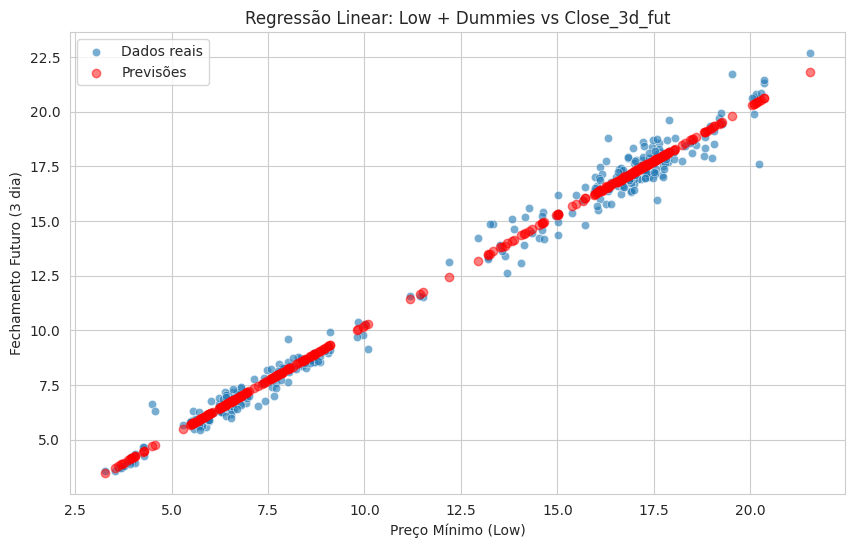

In [10]:
y_1d = df_process['Close_3d_fut']

# Variáveis independentes: 'Low', 'dummy_2021', 'dummy_2022'
X = df_process[['Low', 'dummy_2021', 'dummy_2022']]

# Divide os dados em treino e teste
X_train, X_test, y_train_1d, y_test_1d = train_test_split(X, y_1d, test_size=0.2, random_state=42)

# Inicializa e treina o modelo
model_1d = LinearRegression()
model_1d.fit(X_train, y_train_1d)

# Faz previsões
y_pred_1d = model_1d.predict(X_test)

# Visualização
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test['Low'], y=y_test_1d, alpha=0.6, label='Dados reais')
plt.scatter(X_test['Low'], y_pred_1d, color='red', alpha=0.5, label='Previsões')
plt.title('Regressão Linear: Low + Dummies vs Close_3d_fut')
plt.xlabel('Preço Mínimo (Low)')
plt.ylabel('Fechamento Futuro (3 dia)')
plt.legend()
plt.grid(True)
plt.savefig('regressao_low_dummies_close_3d_fut.png')
print("\nGráfico salvo como 'regressao_low_dummies_close_3d_fut.png'")

# Métricas
print("\nMétricas do Modelo com Dummies (Close_3d_fut):")
print(f"Coeficientes: {model_1d.coef_}")
print(f"Intercepto: {model_1d.intercept_:.4f}")
print(f"R-quadrado (R²): {model_1d.score(X_test, y_test_1d):.4f}")


#### Treinando o medelo de regressão linear simples com 2 variaveis dicotômicas Close x Low para 15 dias no futuro


Gráfico salvo como 'regressao_low_dummies_close_15d_fut.png'

Métricas do Modelo com Dummies (Close_15d_fut):
Coeficientes: [0.94308303 0.30369721 0.11372271]
Intercepto: 0.8301
R-quadrado (R²): 0.9622


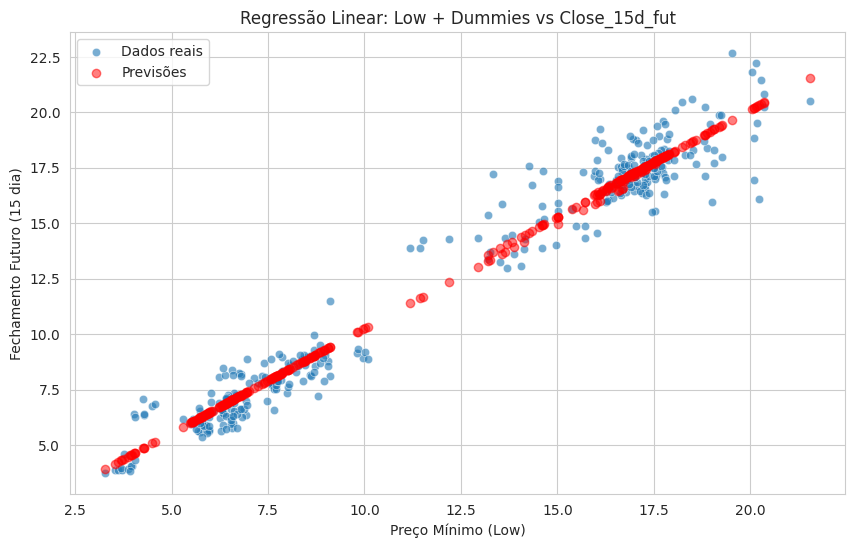

In [11]:
y_1d = df_process['Close_15d_fut']

# Variáveis independentes: 'Low', 'dummy_2021', 'dummy_2022'
X = df_process[['Low', 'dummy_2021', 'dummy_2022']]

# Divide os dados em treino e teste
X_train, X_test, y_train_1d, y_test_1d = train_test_split(X, y_1d, test_size=0.2, random_state=42)

# Inicializa e treina o modelo
model_1d = LinearRegression()
model_1d.fit(X_train, y_train_1d)

# Faz previsões
y_pred_1d = model_1d.predict(X_test)

# Visualização
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test['Low'], y=y_test_1d, alpha=0.6, label='Dados reais')
plt.scatter(X_test['Low'], y_pred_1d, color='red', alpha=0.5, label='Previsões')
plt.title('Regressão Linear: Low + Dummies vs Close_15d_fut')
plt.xlabel('Preço Mínimo (Low)')
plt.ylabel('Fechamento Futuro (15 dia)')
plt.legend()
plt.grid(True)
plt.savefig('regressao_low_dummies_close_15d_fut.png')
print("\nGráfico salvo como 'regressao_low_dummies_close_15d_fut.png'")

# Métricas
print("\nMétricas do Modelo com Dummies (Close_15d_fut):")
print(f"Coeficientes: {model_1d.coef_}")
print(f"Intercepto: {model_1d.intercept_:.4f}")
print(f"R-quadrado (R²): {model_1d.score(X_test, y_test_1d):.4f}")


#### Treinando o medelo de regressão linear simples com 2 variaveis dicotômicas Close x Low para 30 dias no futuro


Gráfico salvo como 'regressao_low_dummies_close_30d_fut.png'

Matriz de correlação salva como 'correlacao_low_dummies_close_30d_fut.png'

Métricas do Modelo com Dummies (Close_30d_fut):
Coeficientes: [0.87618184 0.73132132 0.0946605 ]
Intercepto: 1.5853
R-quadrado (R²): 0.9158
Erro Absoluto Médio (MAE): 1.2022

Matriz de correlação salva como 'correlacao_low_dummies_close_30d_fut.png'

Métricas do Modelo com Dummies (Close_30d_fut):
Coeficientes: [0.87618184 0.73132132 0.0946605 ]
Intercepto: 1.5853
R-quadrado (R²): 0.9158
Erro Absoluto Médio (MAE): 1.2022


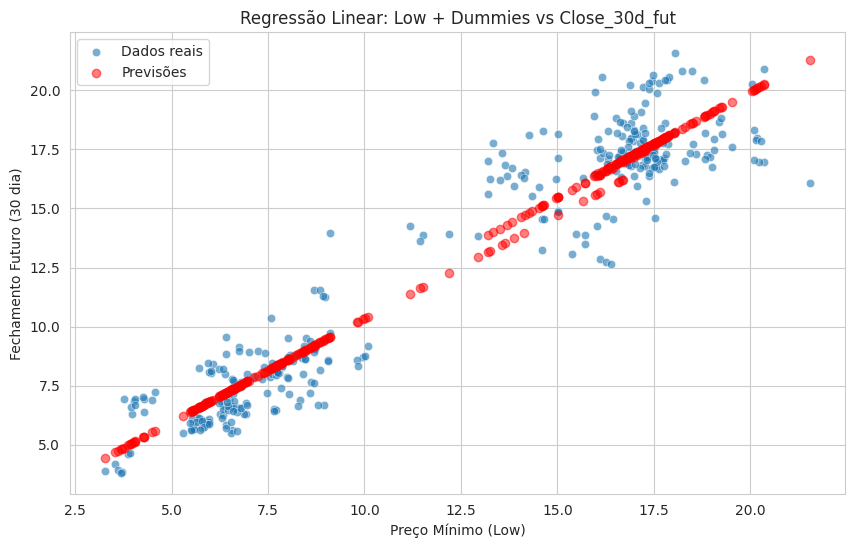

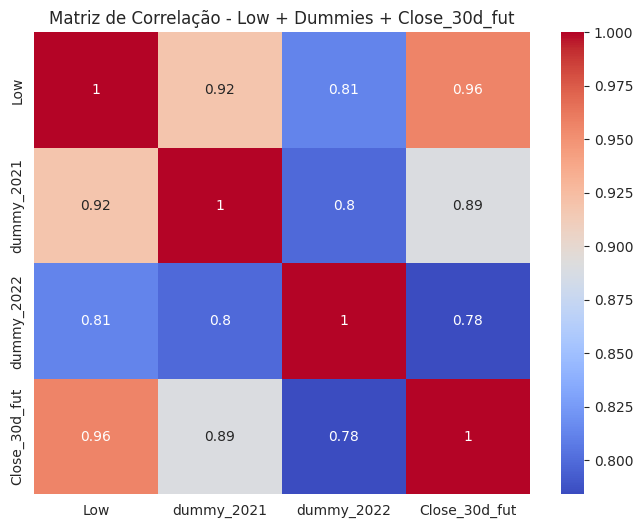

In [12]:
# Regressão Close_30d_fut ~ Low + dummies
y_1d = df_process['Close_30d_fut']
X = df_process[['Low', 'dummy_2021', 'dummy_2022']]
X_train, X_test, y_train_1d, y_test_1d = train_test_split(X, y_1d, test_size=0.2, random_state=42)
model_1d = LinearRegression()
model_1d.fit(X_train, y_train_1d)
y_pred_1d = model_1d.predict(X_test)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test['Low'], y=y_test_1d, alpha=0.6, label='Dados reais')
plt.scatter(X_test['Low'], y_pred_1d, color='red', alpha=0.5, label='Previsões')
plt.title('Regressão Linear: Low + Dummies vs Close_30d_fut')
plt.xlabel('Preço Mínimo (Low)')
plt.ylabel('Fechamento Futuro (30 dia)')
plt.legend()
plt.grid(True)
plt.savefig('regressao_low_dummies_close_30d_fut.png')
print("\nGráfico salvo como 'regressao_low_dummies_close_30d_fut.png'")

# Matriz de correlação
corr_matrix = df_process[['Low', 'dummy_2021', 'dummy_2022', 'Close_30d_fut']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Matriz de Correlação - Low + Dummies + Close_30d_fut')
plt.savefig('correlacao_low_dummies_close_30d_fut.png')
print("\nMatriz de correlação salva como 'correlacao_low_dummies_close_30d_fut.png'")

# Métricas
mae_low_30d = mean_absolute_error(y_test_1d, y_pred_1d)
print("\nMétricas do Modelo com Dummies (Close_30d_fut):")
print(f"Coeficientes: {model_1d.coef_}")
print(f"Intercepto: {model_1d.intercept_:.4f}")
print(f"R-quadrado (R²): {model_1d.score(X_test, y_test_1d):.4f}")
print(f"Erro Absoluto Médio (MAE): {mae_low_30d:.4f}")

#### Treinando o modelo de regressão linear simples com 2 variáveis dicotômicas Close x High para 1 dia no futuro


Gráfico salvo como 'regressao_high_dummies_close_1d_fut.png'

Métricas do Modelo com Dummies (High, Close_1d_fut):
Coeficientes: [0.9712159  0.05626323 0.12318545]
Intercepto: 0.0821
R-quadrado (R²): 0.9955


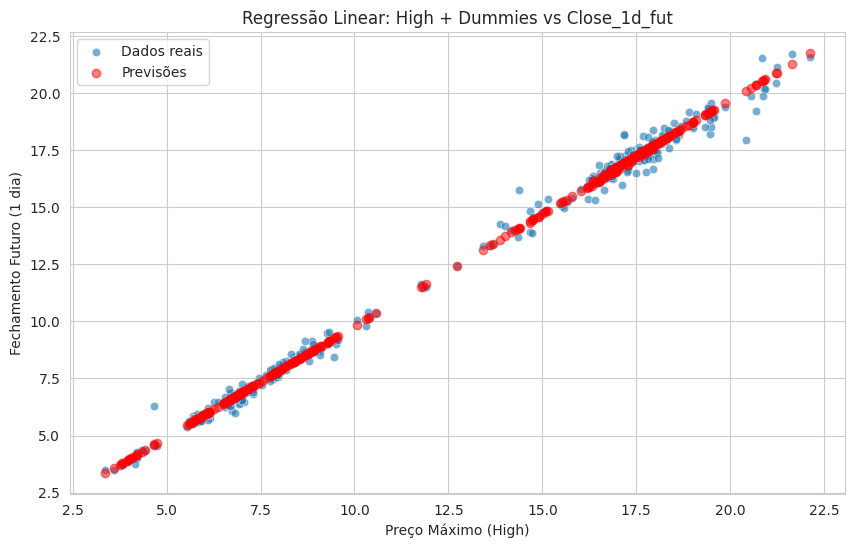

In [13]:
# Regressão Close_1d_fut ~ High + dummies
y_1d = df_process['Close_1d_fut']
X = df_process[['High', 'dummy_2021', 'dummy_2022']]
X_train, X_test, y_train_1d, y_test_1d = train_test_split(X, y_1d, test_size=0.2, random_state=42)
model_1d = LinearRegression()
model_1d.fit(X_train, y_train_1d)
y_pred_1d = model_1d.predict(X_test)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test['High'], y=y_test_1d, alpha=0.6, label='Dados reais')
plt.scatter(X_test['High'], y_pred_1d, color='red', alpha=0.5, label='Previsões')
plt.title('Regressão Linear: High + Dummies vs Close_1d_fut')
plt.xlabel('Preço Máximo (High)')
plt.ylabel('Fechamento Futuro (1 dia)')
plt.legend()
plt.grid(True)
plt.savefig('regressao_high_dummies_close_1d_fut.png')
print("\nGráfico salvo como 'regressao_high_dummies_close_1d_fut.png'")
# Métricas
print("\nMétricas do Modelo com Dummies (High, Close_1d_fut):")
print(f"Coeficientes: {model_1d.coef_}")
print(f"Intercepto: {model_1d.intercept_:.4f}")
print(f"R-quadrado (R²): {model_1d.score(X_test, y_test_1d):.4f}")

#### Treinando o modelo de regressão linear simples com 2 variáveis dicotômicas Close x High para 3 dias no futuro


Gráfico salvo como 'regressao_high_dummies_close_3d_fut.png'

Métricas do Modelo com Dummies (High, Close_3d_fut):
Coeficientes: [0.96151767 0.10500021 0.13225149]
Intercepto: 0.1965
R-quadrado (R²): 0.9898


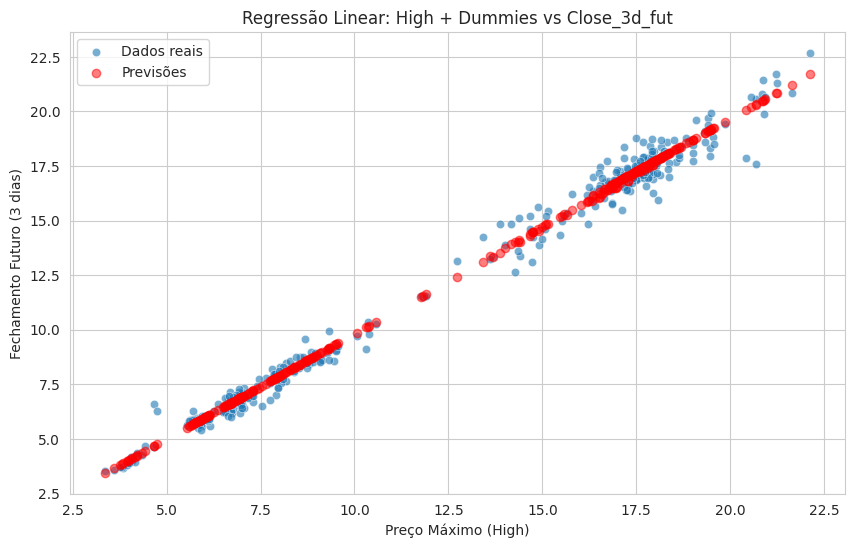

In [14]:
# Regressão Close_3d_fut ~ High + dummies
y_3d = df_process['Close_3d_fut']
X = df_process[['High', 'dummy_2021', 'dummy_2022']]
X_train, X_test, y_train_3d, y_test_3d = train_test_split(X, y_3d, test_size=0.2, random_state=42)
model_3d = LinearRegression()
model_3d.fit(X_train, y_train_3d)
y_pred_3d = model_3d.predict(X_test)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test['High'], y=y_test_3d, alpha=0.6, label='Dados reais')
plt.scatter(X_test['High'], y_pred_3d, color='red', alpha=0.5, label='Previsões')
plt.title('Regressão Linear: High + Dummies vs Close_3d_fut')
plt.xlabel('Preço Máximo (High)')
plt.ylabel('Fechamento Futuro (3 dias)')
plt.legend()
plt.grid(True)
plt.savefig('regressao_high_dummies_close_3d_fut.png')
print("\nGráfico salvo como 'regressao_high_dummies_close_3d_fut.png'")
# Métricas
print("\nMétricas do Modelo com Dummies (High, Close_3d_fut):")
print(f"Coeficientes: {model_3d.coef_}")
print(f"Intercepto: {model_3d.intercept_:.4f}")
print(f"R-quadrado (R²): {model_3d.score(X_test, y_test_3d):.4f}")

#### Treinando o modelo de regressão linear simples com 2 variáveis dicotômicas Close x High para 15 dias no futuro


Gráfico salvo como 'regressao_high_dummies_close_15d_fut.png'

Métricas do Modelo com Dummies (High, Close_15d_fut):
Coeficientes: [0.90246783 0.34841011 0.30002985]
Intercepto: 0.8580
R-quadrado (R²): 0.9629


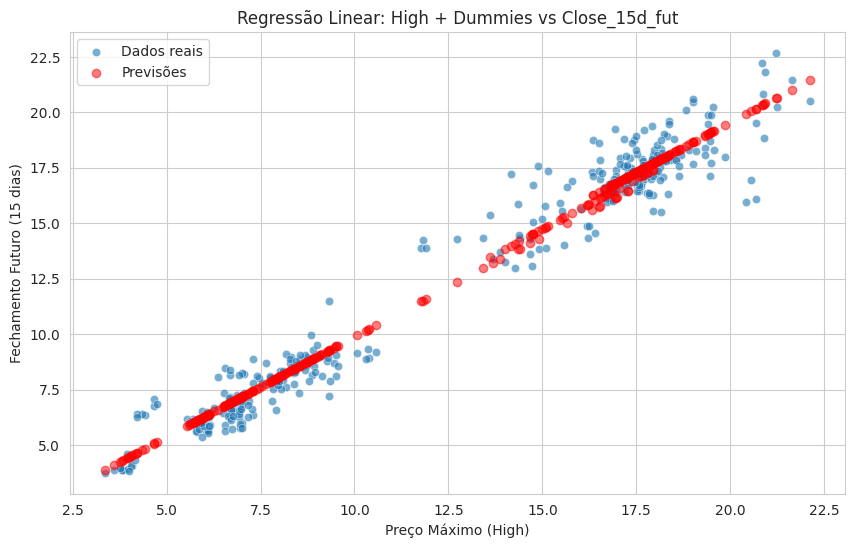

In [15]:
# Regressão Close_15d_fut ~ High + dummies
y_15d = df_process['Close_15d_fut']
X = df_process[['High', 'dummy_2021', 'dummy_2022']]
X_train, X_test, y_train_15d, y_test_15d = train_test_split(X, y_15d, test_size=0.2, random_state=42)
model_15d = LinearRegression()
model_15d.fit(X_train, y_train_15d)
y_pred_15d = model_15d.predict(X_test)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test['High'], y=y_test_15d, alpha=0.6, label='Dados reais')
plt.scatter(X_test['High'], y_pred_15d, color='red', alpha=0.5, label='Previsões')
plt.title('Regressão Linear: High + Dummies vs Close_15d_fut')
plt.xlabel('Preço Máximo (High)')
plt.ylabel('Fechamento Futuro (15 dias)')
plt.legend()
plt.grid(True)
plt.savefig('regressao_high_dummies_close_15d_fut.png')
print("\nGráfico salvo como 'regressao_high_dummies_close_15d_fut.png'")
# Métricas
print("\nMétricas do Modelo com Dummies (High, Close_15d_fut):")
print(f"Coeficientes: {model_15d.coef_}")
print(f"Intercepto: {model_15d.intercept_:.4f}")
print(f"R-quadrado (R²): {model_15d.score(X_test, y_test_15d):.4f}")

#### Treinando o modelo de regressão linear simples com 2 variáveis dicotômicas Close x High para 30 dias no futuro


Gráfico salvo como 'regressao_high_dummies_close_30d_fut.png'

Matriz de correlação salva como 'correlacao_high_dummies_close_30d_fut.png'

Métricas do Modelo com Dummies (High, Close_30d_fut):
Coeficientes: [0.83799079 0.77661699 0.26878433]
Intercepto: 1.6148
R-quadrado (R²): 0.9166
Erro Absoluto Médio (MAE): 1.1924

Matriz de correlação salva como 'correlacao_high_dummies_close_30d_fut.png'

Métricas do Modelo com Dummies (High, Close_30d_fut):
Coeficientes: [0.83799079 0.77661699 0.26878433]
Intercepto: 1.6148
R-quadrado (R²): 0.9166
Erro Absoluto Médio (MAE): 1.1924


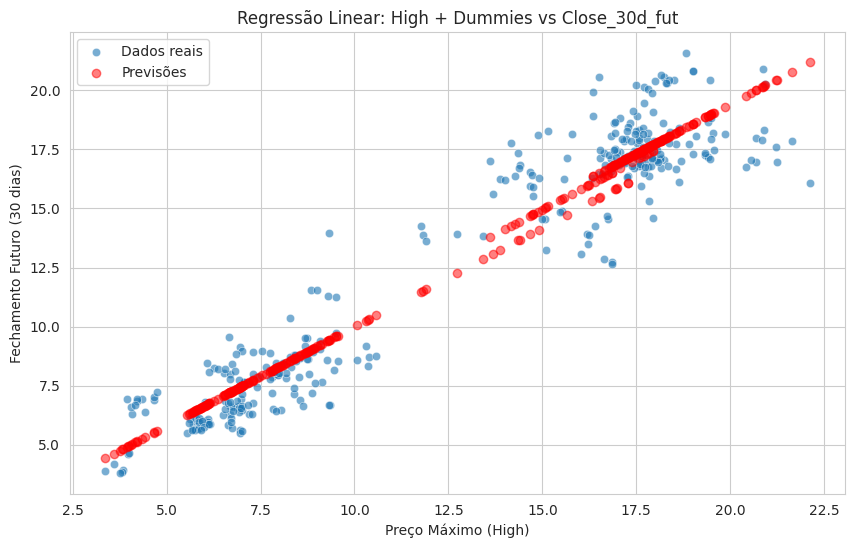

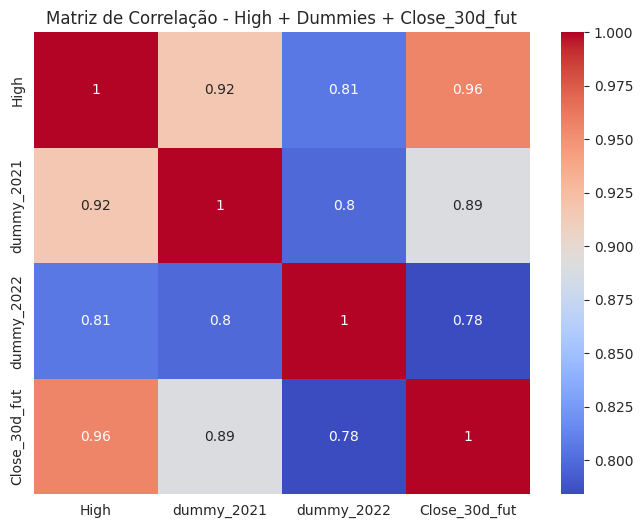

In [16]:
# Regressão Close_30d_fut ~ High + dummies
y_30d = df_process['Close_30d_fut']
X = df_process[['High', 'dummy_2021', 'dummy_2022']]
X_train, X_test, y_train_30d, y_test_30d = train_test_split(X, y_30d, test_size=0.2, random_state=42)
model_30d = LinearRegression()
model_30d.fit(X_train, y_train_30d)
y_pred_30d = model_30d.predict(X_test)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test['High'], y=y_test_30d, alpha=0.6, label='Dados reais')
plt.scatter(X_test['High'], y_pred_30d, color='red', alpha=0.5, label='Previsões')
plt.title('Regressão Linear: High + Dummies vs Close_30d_fut')
plt.xlabel('Preço Máximo (High)')
plt.ylabel('Fechamento Futuro (30 dias)')
plt.legend()
plt.grid(True)
plt.savefig('regressao_high_dummies_close_30d_fut.png')
print("\nGráfico salvo como 'regressao_high_dummies_close_30d_fut.png'")

# Matriz de correlação
corr_matrix = df_process[['High', 'dummy_2021', 'dummy_2022', 'Close_30d_fut']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Matriz de Correlação - High + Dummies + Close_30d_fut')
plt.savefig('correlacao_high_dummies_close_30d_fut.png')
print("\nMatriz de correlação salva como 'correlacao_high_dummies_close_30d_fut.png'")

# Métricas
mae_high_30d = mean_absolute_error(y_test_30d, y_pred_30d)
print("\nMétricas do Modelo com Dummies (High, Close_30d_fut):")
print(f"Coeficientes: {model_30d.coef_}")
print(f"Intercepto: {model_30d.intercept_:.4f}")
print(f"R-quadrado (R²): {model_30d.score(X_test, y_test_30d):.4f}")
print(f"Erro Absoluto Médio (MAE): {mae_high_30d:.4f}")

#### Treinando o modelo de regressão linear simples com 2 variáveis dicotômicas Close x Open para 1 dia no futuro


Gráfico salvo como 'regressao_open_dummies_close_1d_fut.png'

Métricas do Modelo com Dummies (Open, Close_1d_fut):
Coeficientes: [0.98774187 0.05356001 0.05360747]
Intercepto: 0.1077
R-quadrado (R²): 0.9941


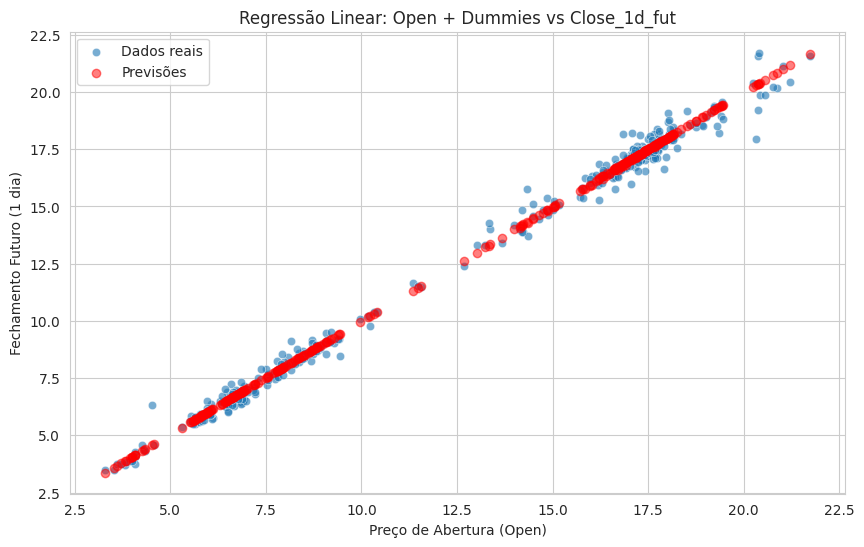

In [17]:
# Regressão Close_1d_fut ~ Open + dummies
y_1d = df_process['Close_1d_fut']
X = df_process[['Open', 'dummy_2021', 'dummy_2022']]
X_train, X_test, y_train_1d, y_test_1d = train_test_split(X, y_1d, test_size=0.2, random_state=42)
model_1d = LinearRegression()
model_1d.fit(X_train, y_train_1d)
y_pred_1d = model_1d.predict(X_test)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test['Open'], y=y_test_1d, alpha=0.6, label='Dados reais')
plt.scatter(X_test['Open'], y_pred_1d, color='red', alpha=0.5, label='Previsões')
plt.title('Regressão Linear: Open + Dummies vs Close_1d_fut')
plt.xlabel('Preço de Abertura (Open)')
plt.ylabel('Fechamento Futuro (1 dia)')
plt.legend()
plt.grid(True)
plt.savefig('regressao_open_dummies_close_1d_fut.png')
print("\nGráfico salvo como 'regressao_open_dummies_close_1d_fut.png'")
# Métricas
print("\nMétricas do Modelo com Dummies (Open, Close_1d_fut):")
print(f"Coeficientes: {model_1d.coef_}")
print(f"Intercepto: {model_1d.intercept_:.4f}")
print(f"R-quadrado (R²): {model_1d.score(X_test, y_test_1d):.4f}")

#### Treinando o modelo de regressão linear simples com 2 variáveis dicotômicas Close x Open para 3 dias no futuro


Gráfico salvo como 'regressao_open_dummies_close_3d_fut.png'

Métricas do Modelo com Dummies (Open, Close_3d_fut):
Coeficientes: [0.97783425 0.1026825  0.06347003]
Intercepto: 0.2222
R-quadrado (R²): 0.9877


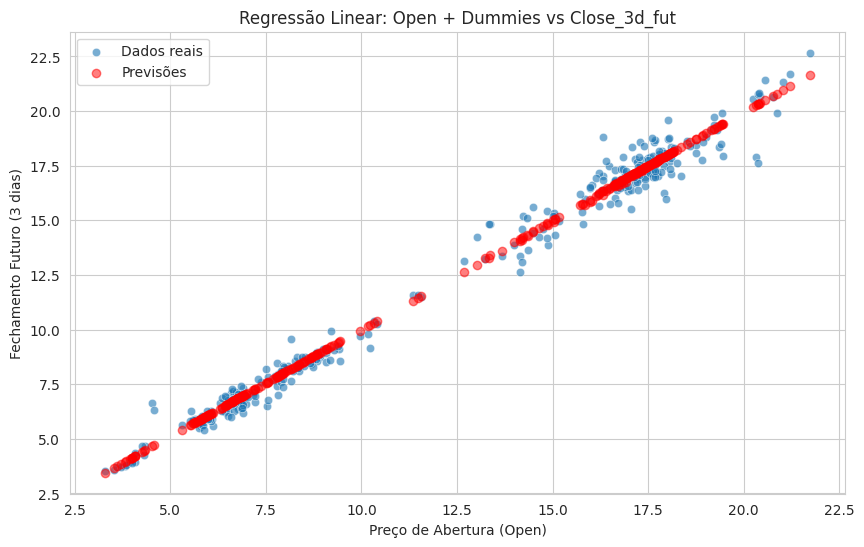

In [18]:
# Regressão Close_3d_fut ~ Open + dummies
y_3d = df_process['Close_3d_fut']
X = df_process[['Open', 'dummy_2021', 'dummy_2022']]
X_train, X_test, y_train_3d, y_test_3d = train_test_split(X, y_3d, test_size=0.2, random_state=42)
model_3d = LinearRegression()
model_3d.fit(X_train, y_train_3d)
y_pred_3d = model_3d.predict(X_test)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test['Open'], y=y_test_3d, alpha=0.6, label='Dados reais')
plt.scatter(X_test['Open'], y_pred_3d, color='red', alpha=0.5, label='Previsões')
plt.title('Regressão Linear: Open + Dummies vs Close_3d_fut')
plt.xlabel('Preço de Abertura (Open)')
plt.ylabel('Fechamento Futuro (3 dias)')
plt.legend()
plt.grid(True)
plt.savefig('regressao_open_dummies_close_3d_fut.png')
print("\nGráfico salvo como 'regressao_open_dummies_close_3d_fut.png'")
# Métricas
print("\nMétricas do Modelo com Dummies (Open, Close_3d_fut):")
print(f"Coeficientes: {model_3d.coef_}")
print(f"Intercepto: {model_3d.intercept_:.4f}")
print(f"R-quadrado (R²): {model_3d.score(X_test, y_test_3d):.4f}")

#### Treinando o modelo de regressão linear simples com 2 variáveis dicotômicas Close x Open para 15 dias no futuro


Gráfico salvo como 'regressao_open_dummies_close_15d_fut.png'

Métricas do Modelo com Dummies (Open, Close_15d_fut):
Coeficientes: [0.91866204 0.33912685 0.23345541]
Intercepto: 0.8754
R-quadrado (R²): 0.9600


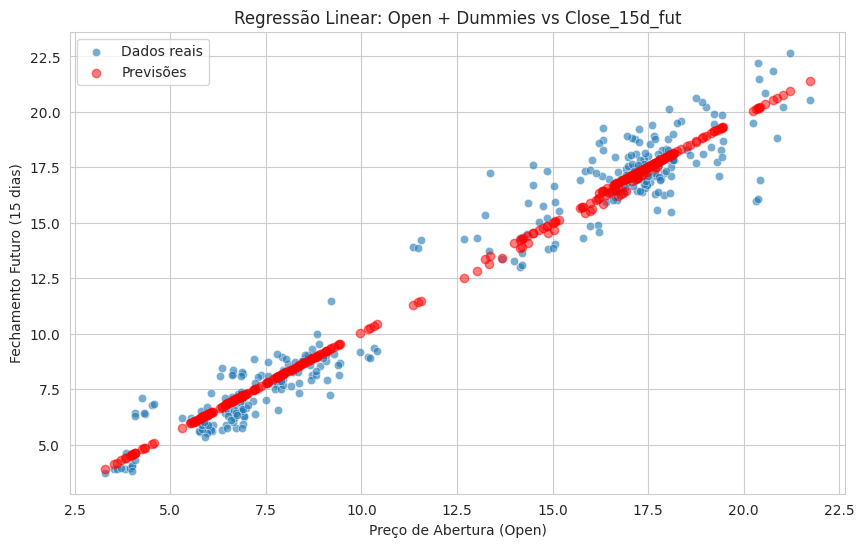

In [19]:
# Regressão Close_15d_fut ~ Open + dummies
y_15d = df_process['Close_15d_fut']
X = df_process[['Open', 'dummy_2021', 'dummy_2022']]
X_train, X_test, y_train_15d, y_test_15d = train_test_split(X, y_15d, test_size=0.2, random_state=42)
model_15d = LinearRegression()
model_15d.fit(X_train, y_train_15d)
y_pred_15d = model_15d.predict(X_test)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test['Open'], y=y_test_15d, alpha=0.6, label='Dados reais')
plt.scatter(X_test['Open'], y_pred_15d, color='red', alpha=0.5, label='Previsões')
plt.title('Regressão Linear: Open + Dummies vs Close_15d_fut')
plt.xlabel('Preço de Abertura (Open)')
plt.ylabel('Fechamento Futuro (15 dias)')
plt.legend()
plt.grid(True)
plt.savefig('regressao_open_dummies_close_15d_fut.png')
print("\nGráfico salvo como 'regressao_open_dummies_close_15d_fut.png'")
# Métricas
print("\nMétricas do Modelo com Dummies (Open, Close_15d_fut):")
print(f"Coeficientes: {model_15d.coef_}")
print(f"Intercepto: {model_15d.intercept_:.4f}")
print(f"R-quadrado (R²): {model_15d.score(X_test, y_test_15d):.4f}")

#### Treinando o modelo de regressão linear simples com 2 variáveis dicotômicas Close x Open para 30 dias no futuro


Gráfico salvo como 'regressao_open_dummies_close_30d_fut.png'

Matriz de correlação salva como 'correlacao_open_dummies_close_30d_fut.png'

Métricas do Modelo com Dummies (Open, Close_30d_fut):
Coeficientes: [0.85405271 0.75971717 0.2046167 ]
Intercepto: 1.6231
R-quadrado (R²): 0.9134
Erro Absoluto Médio (MAE): 1.2165

Matriz de correlação salva como 'correlacao_open_dummies_close_30d_fut.png'

Métricas do Modelo com Dummies (Open, Close_30d_fut):
Coeficientes: [0.85405271 0.75971717 0.2046167 ]
Intercepto: 1.6231
R-quadrado (R²): 0.9134
Erro Absoluto Médio (MAE): 1.2165


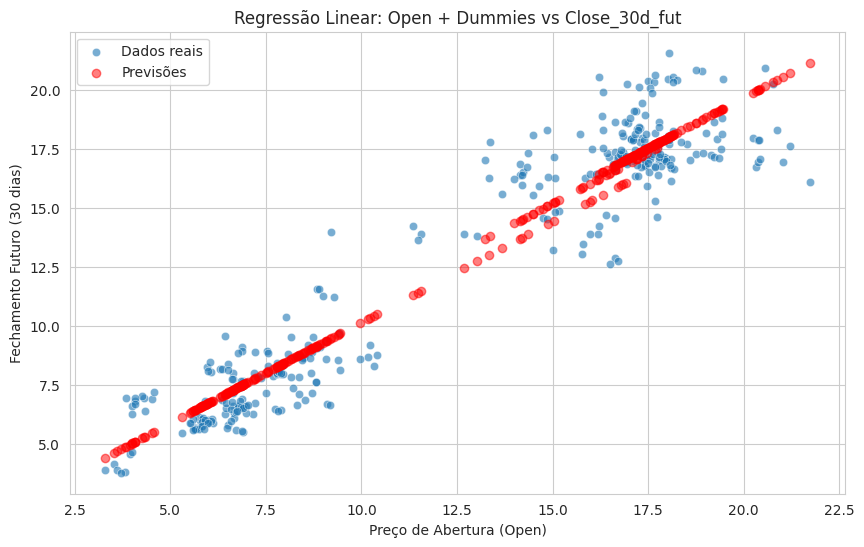

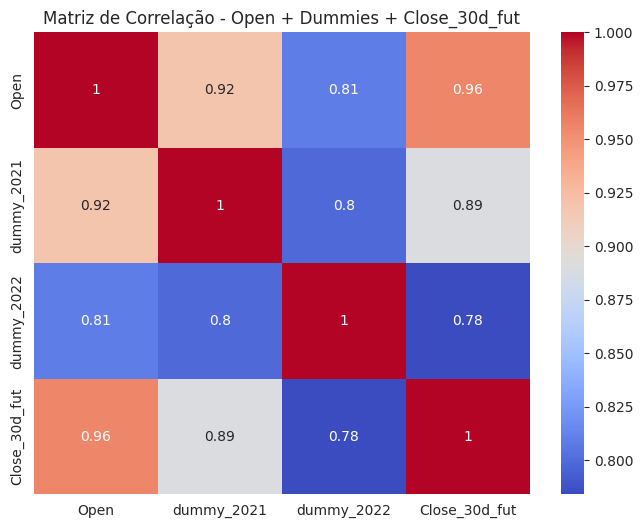

In [22]:
# Regressão Close_30d_fut ~ Open + dummies
y_30d = df_process['Close_30d_fut']
X = df_process[['Open', 'dummy_2021', 'dummy_2022']]
X_train, X_test, y_train_30d, y_test_30d = train_test_split(X, y_30d, test_size=0.2, random_state=42)
model_30d = LinearRegression()
model_30d.fit(X_train, y_train_30d)
y_pred_30d = model_30d.predict(X_test)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test['Open'], y=y_test_30d, alpha=0.6, label='Dados reais')
plt.scatter(X_test['Open'], y_pred_30d, color='red', alpha=0.5, label='Previsões')
plt.title('Regressão Linear: Open + Dummies vs Close_30d_fut')
plt.xlabel('Preço de Abertura (Open)')
plt.ylabel('Fechamento Futuro (30 dias)')
plt.legend()
plt.grid(True)
plt.savefig('regressao_open_dummies_close_30d_fut.png')
print("\nGráfico salvo como 'regressao_open_dummies_close_30d_fut.png'")

# Matriz de correlação
corr_matrix = df_process[['Open', 'dummy_2021', 'dummy_2022', 'Close_30d_fut']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Matriz de Correlação - Open + Dummies + Close_30d_fut')
plt.savefig('correlacao_open_dummies_close_30d_fut.png')
print("\nMatriz de correlação salva como 'correlacao_open_dummies_close_30d_fut.png'")

# Métricas
mae_open_30d = mean_absolute_error(y_test_30d, y_pred_30d)
print("\nMétricas do Modelo com Dummies (Open, Close_30d_fut):")
print(f"Coeficientes: {model_30d.coef_}")
print(f"Intercepto: {model_30d.intercept_:.4f}")
print(f"R-quadrado (R²): {model_30d.score(X_test, y_test_30d):.4f}")
print(f"Erro Absoluto Médio (MAE): {mae_open_30d:.4f}")

#### Modelo de Série Temporal: Previsão de Close_30d_fut usando Low


Gráfico da série temporal salvo como 'serie_temporal_close30d_low.png'

Gráfico de previsão salvo como 'arima_close30d_low.png'
Erro Quadrático Médio (MSE): 0.84
Erro Absoluto Médio (MAE): 0.72
Este modelo ARIMA utiliza a variável Low como exógena para prever o fechamento em 30 dias. Avalie os gráficos e métricas para entender o desempenho.

Gráfico de previsão salvo como 'arima_close30d_low.png'
Erro Quadrático Médio (MSE): 0.84
Erro Absoluto Médio (MAE): 0.72
Este modelo ARIMA utiliza a variável Low como exógena para prever o fechamento em 30 dias. Avalie os gráficos e métricas para entender o desempenho.


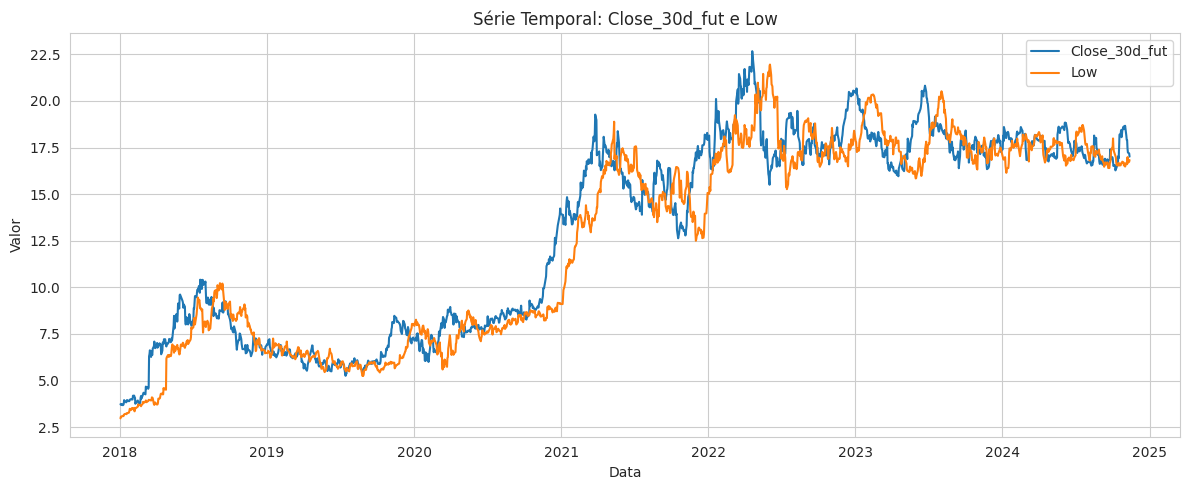

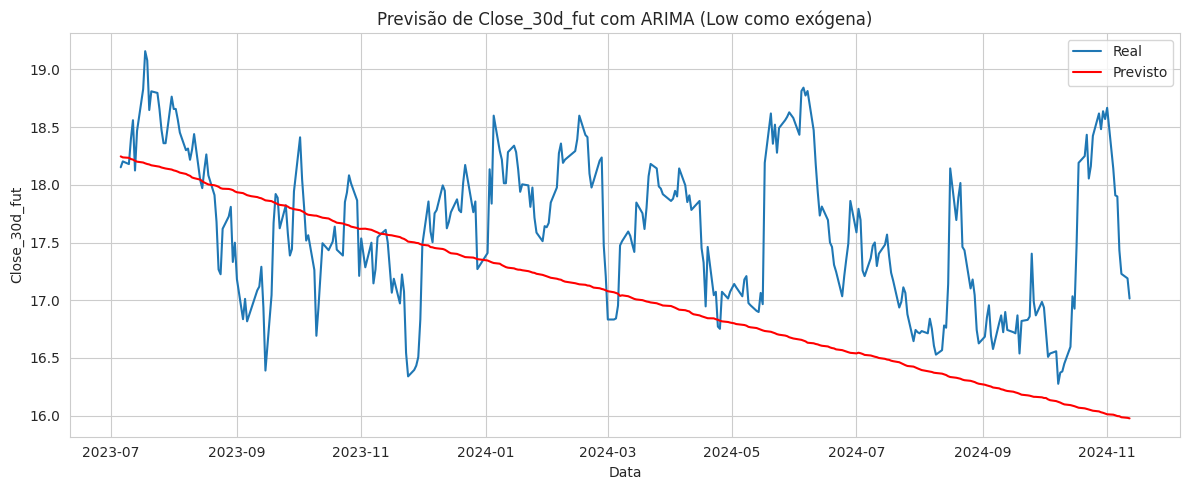

In [21]:
# Modelo de Série Temporal para previsão de Close_30d_fut usando Low
# Este exemplo utiliza ARIMA, que é um dos modelos mais comuns para séries temporais.
# Para rodar, certifique-se de ter o pacote 'statsmodels' instalado: pip install statsmodels
from statsmodels.tsa.arima.model import ARIMA
import numpy as np
import warnings
warnings.filterwarnings('ignore')
# Organiza os dados para série temporal
# Usamos apenas as colunas de interesse e garantimos que o índice seja temporal
ts_df = df_process[['Low', 'Close_30d_fut']].copy()
ts_df = ts_df.sort_index()
# Visualiza a série temporal
plt.figure(figsize=(12,5))
plt.plot(ts_df.index, ts_df['Close_30d_fut'], label='Close_30d_fut')
plt.plot(ts_df.index, ts_df['Low'], label='Low')
plt.title('Série Temporal: Close_30d_fut e Low')
plt.xlabel('Data')
plt.ylabel('Valor')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('serie_temporal_close30d_low.png')
print("\nGráfico da série temporal salvo como 'serie_temporal_close30d_low.png'")
# Treinamento do modelo ARIMA
# O ARIMA tradicional modela apenas uma série, mas podemos usar Low como exógena (ARIMAX)
# Dividindo em treino e teste
train_size = int(len(ts_df) * 0.8)
train, test = ts_df.iloc[:train_size], ts_df.iloc[train_size:]
# Treina o modelo ARIMA com Low como variável exógena
model = ARIMA(train['Close_30d_fut'], exog=train[['Low']], order=(1,0,0))
model_fit = model.fit()
# Faz previsões
forecast = model_fit.predict(start=len(train), end=len(train) + len(test) - 1, exog=test[['Low']])
# Visualiza as previsões
plt.figure(figsize=(12,5))
plt.plot(test.index, test['Close_30d_fut'], label='Real')
plt.plot(test.index, forecast, label='Previsto', color='red')
plt.title('Previsão de Close_30d_fut com ARIMA (Low como exógena)')
plt.xlabel('Data')
plt.ylabel('Close_30d_fut')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('arima_close30d_low.png')
print("\nGráfico de previsão salvo como 'arima_close30d_low.png'")
# Métricas de avaliação
from sklearn.metrics import mean_squared_error, mean_absolute_error
mse = mean_squared_error(test['Close_30d_fut'], forecast)
mae = mean_absolute_error(test['Close_30d_fut'], forecast)
print(f'Erro Quadrático Médio (MSE): {mse:.2f}')
print(f'Erro Absoluto Médio (MAE): {mae:.2f}')
# Comentários:
print('Este modelo ARIMA utiliza a variável Low como exógena para prever o fechamento em 30 dias. Avalie os gráficos e métricas para entender o desempenho.')